# 07 Model Performance Dashboard

Visual diagnostics for the trained PR suggestion coverage classifier. Run this after `03_evaluate`, `05_external`, and `06_train`.

## Setup

In [28]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit

PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from pr_suggestion_metrics.model_inference import prepare_model_features

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10

INTERNAL_DATASET_DIR = PROJECT_ROOT / 'data' / 'processed' / 'pr_suggestion_coverage' / 'dataset'
INTERNAL_SCORES_PATH = PROJECT_ROOT / 'reports' / 'metric_scores.csv'
HF_DATASET_DIR = PROJECT_ROOT / 'data' / 'external' / 'github_codereview' / 'dataset'
HF_SCORES_PATH = PROJECT_ROOT / 'data' / 'external' / 'github_codereview' / 'metric_scores.csv'
MODEL_DIR = PROJECT_ROOT / 'models' / 'pr_suggestion_coverage'
MODEL_PATH = MODEL_DIR / 'model.joblib'
SCHEMA_PATH = MODEL_DIR / 'feature_schema.json'
REPORT_PATH = MODEL_DIR / 'evaluation_report.json'
DASHBOARD_DIR = PROJECT_ROOT / 'reports' / 'model_performance_dashboard'
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True


def save_figure(fig: plt.Figure, name: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(DASHBOARD_DIR / f'{name}.png', dpi=160, bbox_inches='tight')


LABEL_ORDER = ['0%', 'partial', 'mostly', '100%']
LABEL_TO_PERCENTAGE = {'0%': 0, 'partial': 40, 'mostly': 80, '100%': 100}
PERCENTAGE_BUCKET_ORDER = ['0', '1-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']

def percentage_bucket(value: int | float) -> str:
    percentage = max(0, min(100, int(round(value))))
    if percentage == 0:
        return '0'
    lower_bound = ((percentage - 1) // 10) * 10 + 1
    upper_bound = min(lower_bound + 9, 100)
    return f'{lower_bound}-{upper_bound}'

RANDOM_STATE = 42

MODEL_PATH.exists(), SCHEMA_PATH.exists(), REPORT_PATH.exists()

(True, True, True)

## Load Data And Model

In [29]:
def read_labels(dataset_dir: Path) -> pd.DataFrame:
    labels = pd.read_csv(dataset_dir / 'labels.csv')
    keep_columns = ['example_id', 'pr_url', 'repo', 'suggestion_source']
    return labels[[column for column in keep_columns if column in labels.columns]].copy()


def load_source_scores(source_name: str, scores_path: Path, dataset_dir: Path) -> pd.DataFrame:
    scores = pd.read_csv(scores_path)
    labels = read_labels(dataset_dir)
    rows = scores.merge(labels, on='example_id', how='left', suffixes=('', '_label_file'))
    rows['dataset_source'] = source_name
    rows['repo'] = rows['repo'].fillna(source_name + '/unknown')
    rows['pr_url'] = rows['pr_url'].fillna(rows['repo'].astype(str) + '#unknown-pr')
    rows['group_id'] = rows['dataset_source'] + ':' + rows['pr_url'].astype(str)
    return rows


schema = json.loads(SCHEMA_PATH.read_text(encoding='utf-8'))
report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
model = joblib.load(MODEL_PATH)

internal_scores = load_source_scores('internal', INTERNAL_SCORES_PATH, INTERNAL_DATASET_DIR)
hf_scores = load_source_scores('hf_github_codereview', HF_SCORES_PATH, HF_DATASET_DIR)
scores = pd.concat([internal_scores, hf_scores], ignore_index=True)

print('rows:', len(scores))
print('sources:')
print(scores['dataset_source'].value_counts())
print('labels:')
print(scores['label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int))
print('saved model:', schema['model_name'])
scores.head()

rows: 498
sources:
dataset_source
internal                279
hf_github_codereview    219
Name: count, dtype: int64
labels:
label
0%         142
partial     75
mostly      84
100%       197
Name: count, dtype: int64
saved model: random_forest


,example_id,label,expected_landed_percentage,expected_percentage_bucket,predicted_label,predicted_percentage,predicted_percentage_bucket,suggestion_language,tokenizer,exact_normalized_match,...,gumtree_update_ratio,gumtree_move_ratio,gumtree_error,file_overlap_ratio,changed_line_overlap_ratio,pr_url,repo,suggestion_source,dataset_source,group_id
0,cd2b0042572e07b5,mostly,80,71-80,mostly,76,71-80,python,python,False,...,0.0,0.0,disabled,1.0,0.0,https://github.tools.sap/Lenny/pipeline-fl-con...,github.tools.sap/Lenny/pipeline-fl-control-plane,github_review_comment:10154007#suggestion:1,internal,internal:https://github.tools.sap/Lenny/pipeli...
1,d194cf145826059c,0%,0,0,0%,0,0,python,python,False,...,0.0,0.0,disabled,0.0,0.0,https://github.tools.sap/Lenny/pipeline-fl-con...,github.tools.sap/Lenny/pipeline-fl-control-plane,github_review_comment:10007322#suggestion:1,internal,internal:https://github.tools.sap/Lenny/pipeli...
2,dc9e6a6b54b060f0,0%,0,0,0%,0,0,python,python,False,...,0.0,0.0,disabled,0.0,0.0,https://github.tools.sap/Lenny/pipeline-fl-con...,github.tools.sap/Lenny/pipeline-fl-control-plane,github_review_comment:10007323#suggestion:1,internal,internal:https://github.tools.sap/Lenny/pipeli...
3,cc66db418d255fc8,0%,0,0,0%,0,0,python,python,False,...,0.0,0.0,disabled,0.0,0.0,https://github.tools.sap/Lenny/pipeline-fl-con...,github.tools.sap/Lenny/pipeline-fl-control-plane,github_review_comment:10007324#suggestion:1,internal,internal:https://github.tools.sap/Lenny/pipeli...
4,403e90a4c2db4136,100%,100,91-100,mostly,85,81-90,python,python,False,...,0.0,0.0,disabled,1.0,1.0,https://github.tools.sap/Lenny/pipeline-fl-con...,github.tools.sap/Lenny/pipeline-fl-control-plane,github_review_comment:10007325#suggestion:1,internal,internal:https://github.tools.sap/Lenny/pipeli...


## Recreate The Validation Split

In [30]:
def source_aware_group_split(rows: pd.DataFrame, test_size: float = 0.25) -> tuple[np.ndarray, np.ndarray]:
    train_parts: list[np.ndarray] = []
    test_parts: list[np.ndarray] = []

    for _, source_rows in rows.groupby('dataset_source', sort=False):
        source_indices = source_rows.index.to_numpy()
        source_groups = source_rows['group_id'].astype(str)

        if source_groups.nunique() < 2 or len(source_rows) < 4:
            fallback_split = max(1, int(round(len(source_rows) * (1 - test_size))))
            train_parts.append(source_indices[:fallback_split])
            test_parts.append(source_indices[fallback_split:])
            continue

        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
        train_positions, test_positions = next(
            splitter.split(source_rows[schema['feature_columns']], source_rows['label'], groups=source_groups)
        )
        train_parts.append(source_indices[train_positions])
        test_parts.append(source_indices[test_positions])

    return np.concatenate(train_parts), np.concatenate(test_parts)


train_index, test_index = source_aware_group_split(scores, test_size=0.25)
test_rows = scores.loc[test_index].copy()
X_test = prepare_model_features(test_rows, schema)
y_test = test_rows['label'].astype(str)

model_predictions = model.predict(X_test)
test_rows['model_prediction'] = model_predictions
test_rows['rule_prediction'] = test_rows['predicted_label'].astype(str)
test_rows['model_correct'] = test_rows['model_prediction'] == test_rows['label']
test_rows['rule_correct'] = test_rows['rule_prediction'] == test_rows['label']
test_rows['model_percentage'] = test_rows['model_prediction'].map(LABEL_TO_PERCENTAGE)
if 'expected_percentage_bucket' not in test_rows.columns:
    test_rows['expected_percentage_bucket'] = test_rows['expected_landed_percentage'].apply(percentage_bucket)
if 'predicted_percentage_bucket' not in test_rows.columns:
    test_rows['predicted_percentage_bucket'] = test_rows['predicted_percentage'].apply(percentage_bucket)
test_rows['model_percentage_bucket'] = test_rows['model_percentage'].apply(percentage_bucket)
for bucket_column in ['expected_percentage_bucket', 'predicted_percentage_bucket', 'model_percentage_bucket']:
    test_rows[bucket_column] = pd.Categorical(test_rows[bucket_column], categories=PERCENTAGE_BUCKET_ORDER, ordered=True)

if hasattr(model, 'predict_proba'):
    probabilities = model.predict_proba(X_test)
    test_rows['model_confidence'] = probabilities.max(axis=1)
    for index, class_label in enumerate(model.classes_):
        test_rows[f'probability_{class_label}'] = probabilities[:, index]

print('validation rows:', len(test_rows))
print(test_rows['dataset_source'].value_counts())
print(test_rows['label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int))
test_rows[['example_id', 'dataset_source', 'label', 'rule_prediction', 'model_prediction', 'model_correct']].head()

validation rows: 121
dataset_source
internal                70
hf_github_codereview    51
Name: count, dtype: int64
label
0%         29
partial    19
mostly     21
100%       52
Name: count, dtype: int64


,example_id,dataset_source,label,rule_prediction,model_prediction,model_correct
24,fa9f06c7275bcf3e,internal,100%,100%,100%,True
25,71c68b9dedea6319,internal,100%,100%,100%,True
26,d3cd82df9aa5e25c,internal,partial,mostly,mostly,False
34,77efe46a00c47062,internal,mostly,mostly,mostly,True
35,42a10ece27f320b2,internal,mostly,mostly,mostly,True


## Headline Model Comparison

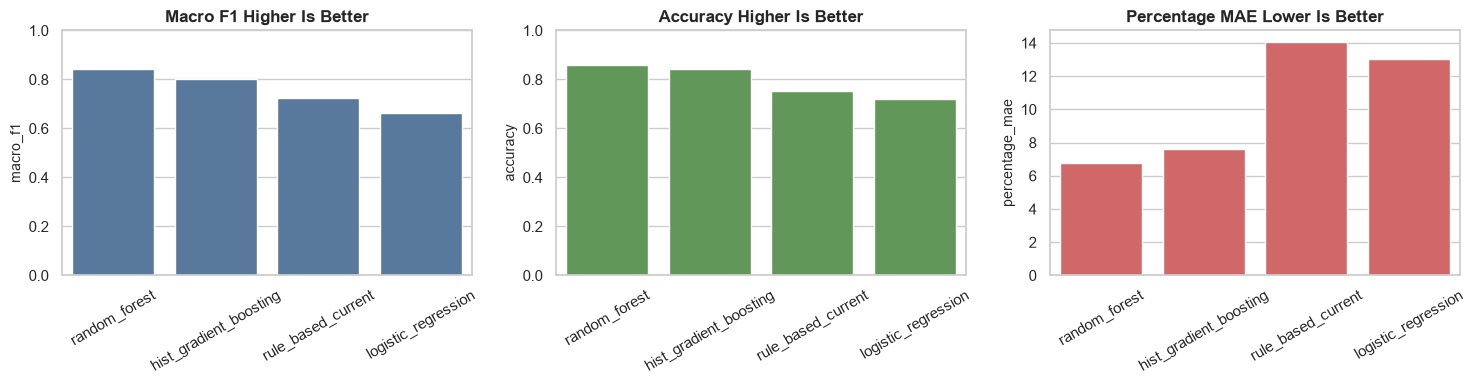

,model,accuracy,macro_f1,percentage_mae
0,random_forest,0.859504,0.844129,6.776860
1,hist_gradient_boosting,0.842975,0.803744,7.603306
2,rule_based_current,0.752066,0.726007,14.049587
3,logistic_regression,0.719008,0.662036,13.057851


In [31]:
evaluation = pd.DataFrame(report['evaluation_table'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=evaluation, x='model', y='macro_f1', ax=axes[0], color='#4C78A8')
axes[0].set_title('Macro F1 Higher Is Better')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=evaluation, x='model', y='accuracy', ax=axes[1], color='#59A14F')
axes[1].set_title('Accuracy Higher Is Better')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=evaluation, x='model', y='percentage_mae', ax=axes[2], color='#E15759')
axes[2].set_title('Percentage MAE Lower Is Better')
axes[2].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
save_figure(fig, 'headline_model_comparison')
plt.show()

evaluation

## Confusion Matrices

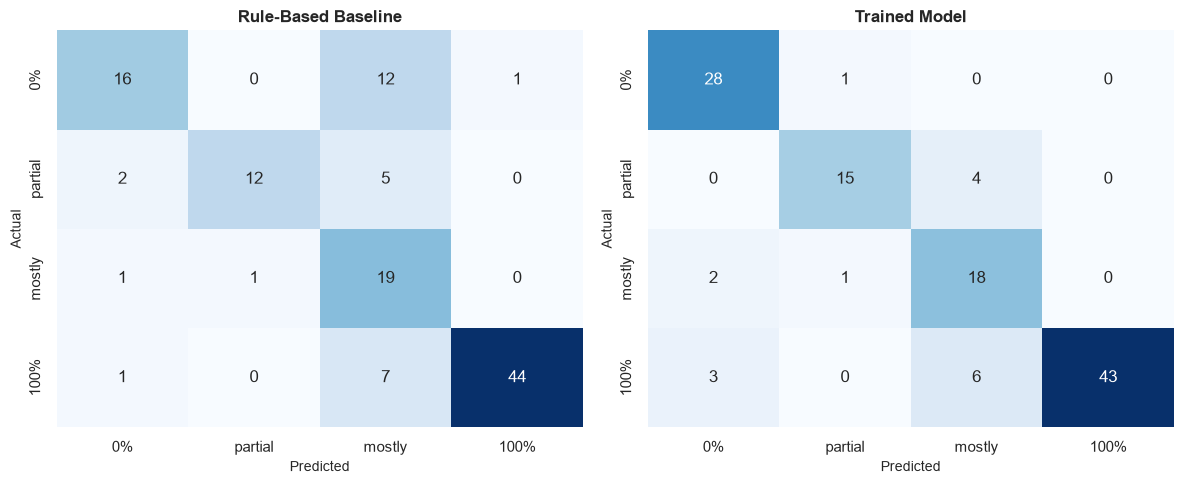

In [32]:
def plot_confusion(ax, actual: pd.Series, predicted: pd.Series, title: str) -> None:
    matrix = confusion_matrix(actual, predicted, labels=LABEL_ORDER)
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        ax=ax,
        cbar=False,
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(axes[0], test_rows['label'], test_rows['rule_prediction'], 'Rule-Based Baseline')
plot_confusion(axes[1], test_rows['label'], test_rows['model_prediction'], 'Trained Model')
plt.tight_layout()
save_figure(fig, 'confusion_matrices')
plt.show()

## Performance By Dataset Source

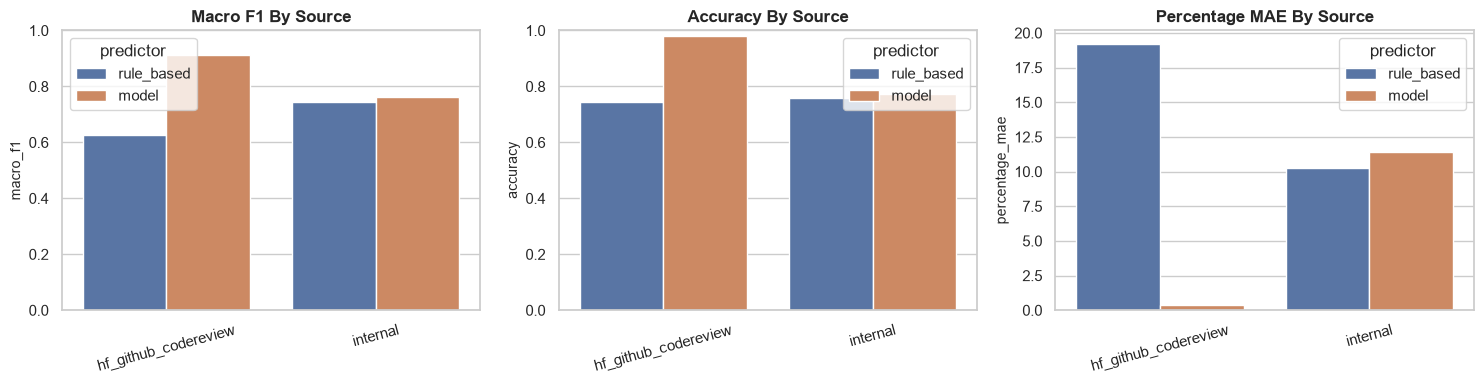

,predictor,rows,accuracy,macro_f1,percentage_mae,dataset_source
0,rule_based,51,0.745098,0.625533,19.215686,hf_github_codereview
1,model,51,0.980392,0.911565,0.392157,hf_github_codereview
2,rule_based,70,0.757143,0.745496,10.285714,internal
3,model,70,0.771429,0.762733,11.428571,internal


In [33]:
def metric_row(rows: pd.DataFrame, prediction_column: str, name: str) -> dict:
    actual = rows['label'].astype(str)
    predicted = rows[prediction_column].astype(str)
    actual_pct = actual.map(LABEL_TO_PERCENTAGE).to_numpy()
    predicted_pct = predicted.map(LABEL_TO_PERCENTAGE).to_numpy()
    return {
        'predictor': name,
        'rows': len(rows),
        'accuracy': accuracy_score(actual, predicted),
        'macro_f1': f1_score(actual, predicted, labels=LABEL_ORDER, average='macro', zero_division=0),
        'percentage_mae': mean_absolute_error(actual_pct, predicted_pct),
    }

source_rows = []
for source, group in test_rows.groupby('dataset_source'):
    rule = metric_row(group, 'rule_prediction', 'rule_based')
    model_row = metric_row(group, 'model_prediction', 'model')
    rule['dataset_source'] = source
    model_row['dataset_source'] = source
    source_rows.extend([rule, model_row])

source_eval = pd.DataFrame(source_rows)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(
    axes,
    ['macro_f1', 'accuracy', 'percentage_mae'],
    ['Macro F1 By Source', 'Accuracy By Source', 'Percentage MAE By Source'],
):
    sns.barplot(data=source_eval, x='dataset_source', y=metric, hue='predictor', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    if metric != 'percentage_mae':
        ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, 'performance_by_source')
plt.show()

source_eval

## Actual Vs Predicted Label Mix

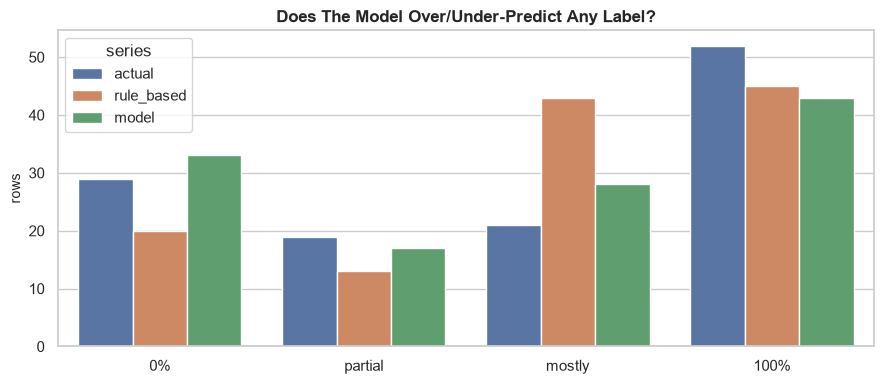

,label,actual,rule_based,model
0,0%,29,20,33
1,partial,19,13,17
2,mostly,21,43,28
3,100%,52,45,43


In [34]:
label_mix = pd.concat([
    test_rows['label'].value_counts().rename('actual'),
    test_rows['rule_prediction'].value_counts().rename('rule_based'),
    test_rows['model_prediction'].value_counts().rename('model'),
], axis=1).reindex(LABEL_ORDER).fillna(0).astype(int).reset_index(names='label')

long_mix = label_mix.melt(id_vars='label', var_name='series', value_name='rows')
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=long_mix, x='label', y='rows', hue='series', ax=ax)
ax.set_title('Does The Model Over/Under-Predict Any Label?')
ax.set_xlabel('')
plt.tight_layout()
save_figure(fig, 'label_mix')
plt.show()

label_mix

## Model Confidence

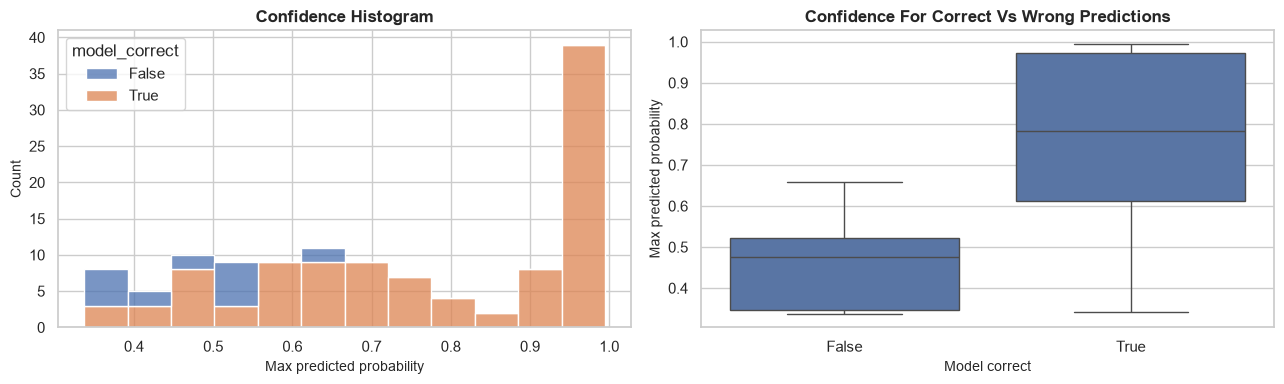

,count,mean,std,min,25%,50%,75%,max
model_correct,,,,,,,,
False,17.0,0.464106,0.100549,0.337193,0.345688,0.475860,0.521892,0.658744
True,104.0,0.774160,0.198640,0.342953,0.612838,0.782207,0.972444,0.994649


In [35]:
if 'model_confidence' not in test_rows.columns:
    print('The saved model does not expose predict_proba().')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(data=test_rows, x='model_confidence', hue='model_correct', bins=12, multiple='stack', ax=axes[0])
    axes[0].set_title('Confidence Histogram')
    axes[0].set_xlabel('Max predicted probability')

    sns.boxplot(data=test_rows, x='model_correct', y='model_confidence', ax=axes[1])
    axes[1].set_title('Confidence For Correct Vs Wrong Predictions')
    axes[1].set_xlabel('Model correct')
    axes[1].set_ylabel('Max predicted probability')
    plt.tight_layout()
    save_figure(fig, 'model_confidence')
    plt.show()

    display(test_rows.groupby('model_correct')['model_confidence'].describe())

## Feature Importance

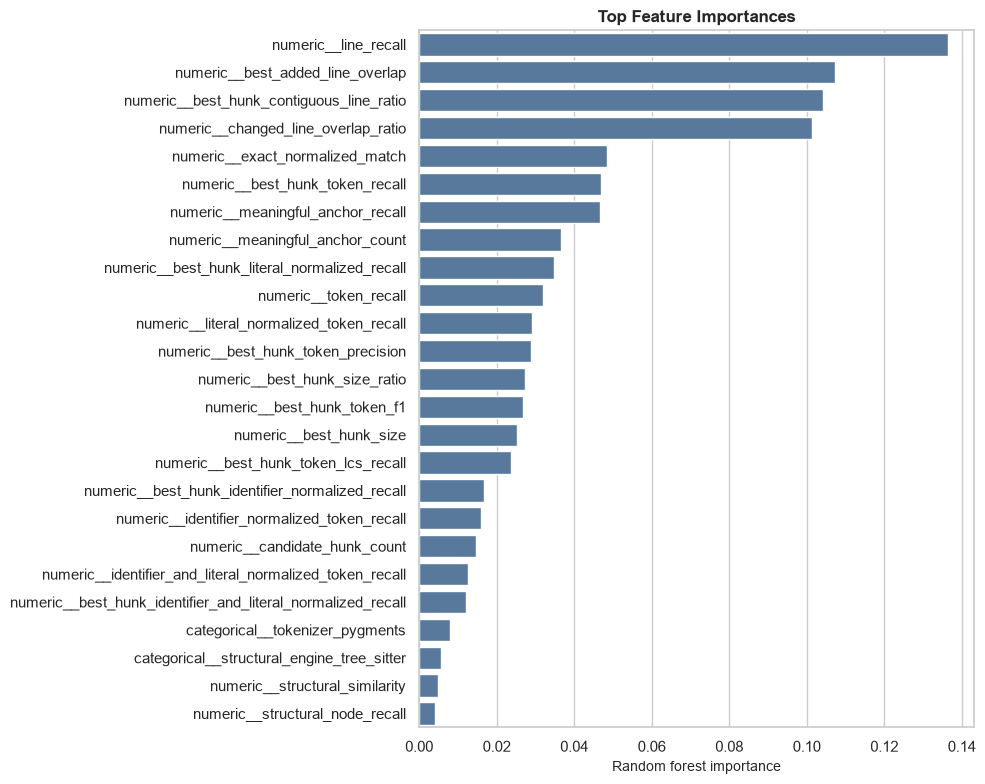

,feature,importance
0,numeric__line_recall,0.136330
5,numeric__best_added_line_overlap,0.107211
12,numeric__best_hunk_contiguous_line_ratio,0.104086
27,numeric__changed_line_overlap_ratio,0.101338
28,numeric__exact_normalized_match,0.048563
6,numeric__best_hunk_token_recall,0.046958
15,numeric__meaningful_anchor_recall,0.046764
16,numeric__meaningful_anchor_count,0.036529
10,numeric__best_hunk_literal_normalized_recall,0.034755
1,numeric__token_recall,0.031962


In [36]:
classifier = model.named_steps.get('classifier') if hasattr(model, 'named_steps') else None
preprocessor = model.named_steps.get('preprocessor') if hasattr(model, 'named_steps') else None

if classifier is None or preprocessor is None or not hasattr(classifier, 'feature_importances_'):
    print('Feature importance is available for tree models such as random_forest. Saved model:', schema['model_name'])
else:
    feature_names = preprocessor.get_feature_names_out()
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': classifier.feature_importances_,
    }).sort_values('importance', ascending=False)
    top_importance = importance.head(25).copy()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=top_importance, x='importance', y='feature', ax=ax, color='#4C78A8')
    ax.set_title('Top Feature Importances')
    ax.set_xlabel('Random forest importance')
    ax.set_ylabel('')
    plt.tight_layout()
    save_figure(fig, 'feature_importance')
    plt.show()

    display(top_importance)

## Metric Distributions By Label

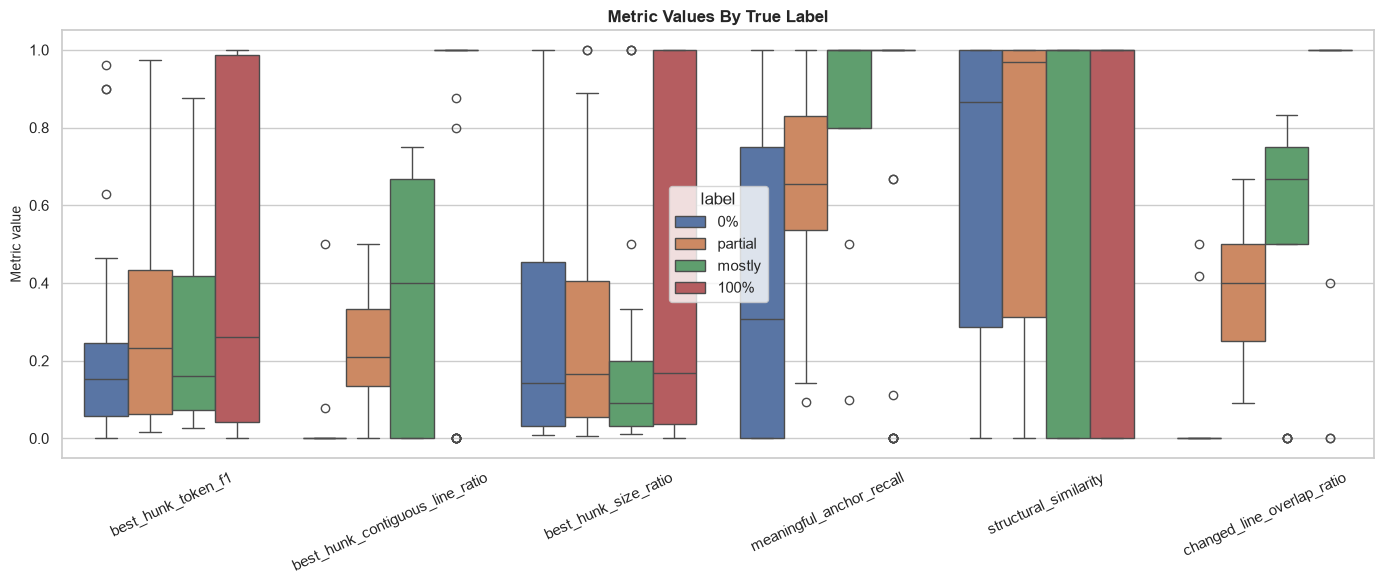

In [37]:
metric_columns = [
    'best_hunk_token_f1',
    'best_hunk_contiguous_line_ratio',
    'best_hunk_size_ratio',
    'meaningful_anchor_recall',
    'structural_similarity',
    'changed_line_overlap_ratio',
]
available_metric_columns = [column for column in metric_columns if column in test_rows.columns]
plot_rows = test_rows.melt(id_vars=['label'], value_vars=available_metric_columns, var_name='metric', value_name='value')
plot_rows['value'] = pd.to_numeric(plot_rows['value'], errors='coerce')

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=plot_rows, x='metric', y='value', hue='label', hue_order=LABEL_ORDER, ax=ax)
ax.set_title('Metric Values By True Label')
ax.set_xlabel('')
ax.set_ylabel('Metric value')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
save_figure(fig, 'metric_distributions_by_label')
plt.show()

## Two-Dimensional Metric View

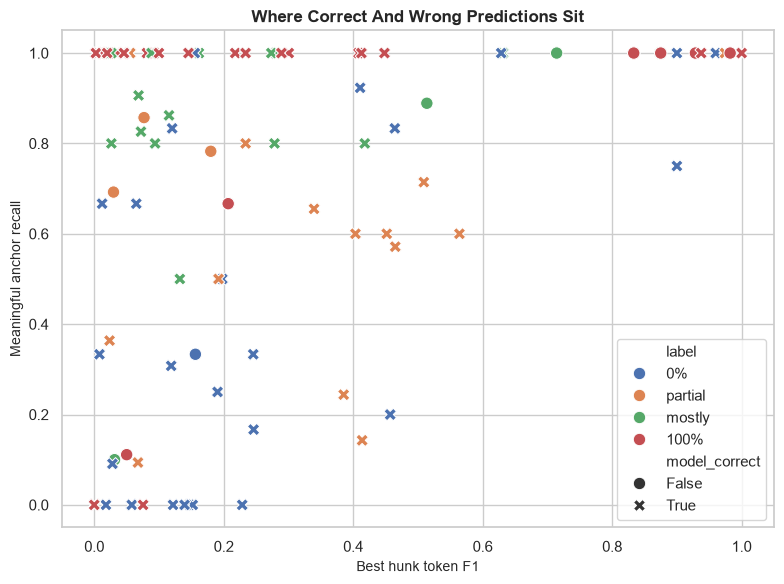

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=test_rows,
    x='best_hunk_token_f1',
    y='meaningful_anchor_recall',
    hue='label',
    style='model_correct',
    hue_order=LABEL_ORDER,
    s=80,
    ax=ax,
)
ax.set_title('Where Correct And Wrong Predictions Sit')
ax.set_xlabel('Best hunk token F1')
ax.set_ylabel('Meaningful anchor recall')
plt.tight_layout()
save_figure(fig, 'metric_scatter_correctness')
plt.show()

## Worst Model Mistakes To Inspect

In [39]:
mistake_columns = [
    'example_id',
    'dataset_source',
    'repo',
    'label',
    'rule_prediction',
    'model_prediction',
    'model_confidence',
    'suggestion_language',
    'best_hunk_token_f1',
    'best_hunk_contiguous_line_ratio',
    'best_hunk_size_ratio',
    'meaningful_anchor_recall',
    'changed_line_overlap_ratio',
]
existing_columns = [column for column in mistake_columns if column in test_rows.columns]
wrong = test_rows.loc[~test_rows['model_correct'], existing_columns].copy()
if 'model_confidence' in wrong.columns:
    wrong = wrong.sort_values('model_confidence', ascending=False)
wrong.head(30)

,example_id,dataset_source,repo,label,rule_prediction,model_prediction,model_confidence,suggestion_language,best_hunk_token_f1,best_hunk_contiguous_line_ratio,best_hunk_size_ratio,meaningful_anchor_recall,changed_line_overlap_ratio
98,0cfb1add02fdf7d9,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,mostly,mostly,0%,0.658744,yaml,0.513761,0.000000,0.333333,0.888889,0.0000
114,0cec9e0b8cb47970,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,100%,0%,0%,0.624479,python,0.050096,0.000000,0.025510,0.111111,0.4000
204,9e2e5cbadb741394,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,partial,0%,mostly,0.529710,python,0.076923,0.200000,0.053191,0.857143,0.4000
26,d3cd82df9aa5e25c,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,partial,mostly,mostly,0.522277,python,0.015974,0.333333,0.009615,1.000000,0.6667
277,eea2dbb7248bc9cc,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,100%,mostly,0%,0.521892,text,0.206897,0.000000,0.125000,0.666667,0.0000
278,996b6a496fafaf75,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,100%,mostly,0%,0.521892,text,0.206897,0.000000,0.125000,0.666667,0.0000
207,a35c44279c5e4e87,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,partial,0%,mostly,0.517231,python,0.180000,0.142857,0.074468,0.782609,0.1429
63,e132b69170c1e4a4,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,0%,mostly,partial,0.514914,python,0.156250,0.500000,0.222222,0.333333,0.5000
62,5a7d126918013fd8,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,mostly,mostly,0%,0.475860,python,0.714286,0.000000,1.000000,1.000000,0.0000
159,6d335ddaa5c1edfc,internal,github.tools.sap/Lenny/pipeline-fl-control-plane,partial,mostly,mostly,0.453903,yaml,0.029764,0.333333,0.009772,0.692308,0.3333


## Percentage Bucket Diagnostics

This keeps `0` separate, then groups coverage into ten-point buckets from `1-10` through `91-100`.

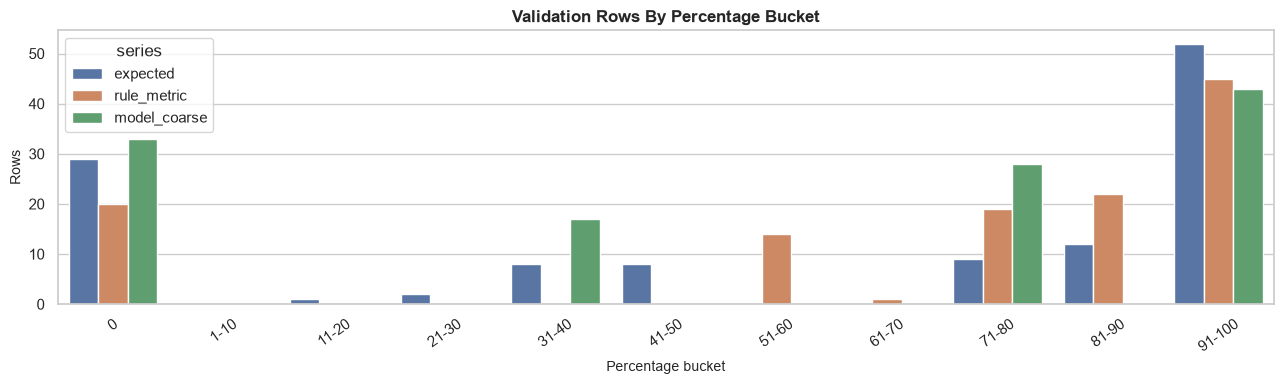

,bucket,expected,rule_metric,model_coarse
0,0,29,20,33
1,1-10,0,0,0
2,11-20,1,0,0
3,21-30,2,0,0
4,31-40,8,0,17
5,41-50,8,0,0
6,51-60,0,14,0
7,61-70,0,1,0
8,71-80,9,19,28
9,81-90,12,22,0


In [40]:
bucket_distribution = pd.concat([
    test_rows['expected_percentage_bucket'].value_counts().rename('expected'),
    test_rows['predicted_percentage_bucket'].value_counts().rename('rule_metric'),
    test_rows['model_percentage_bucket'].value_counts().rename('model_coarse'),
], axis=1).reindex(PERCENTAGE_BUCKET_ORDER).fillna(0).astype(int).reset_index(names='bucket')

long_bucket_distribution = bucket_distribution.melt(id_vars='bucket', var_name='series', value_name='rows')
fig, ax = plt.subplots(figsize=(13, 4))
sns.barplot(data=long_bucket_distribution, x='bucket', y='rows', hue='series', ax=ax)
ax.set_title('Validation Rows By Percentage Bucket')
ax.set_xlabel('Percentage bucket')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
save_figure(fig, 'percentage_bucket_distribution')
plt.show()

bucket_distribution

## Rule Metric Bucket Confusion

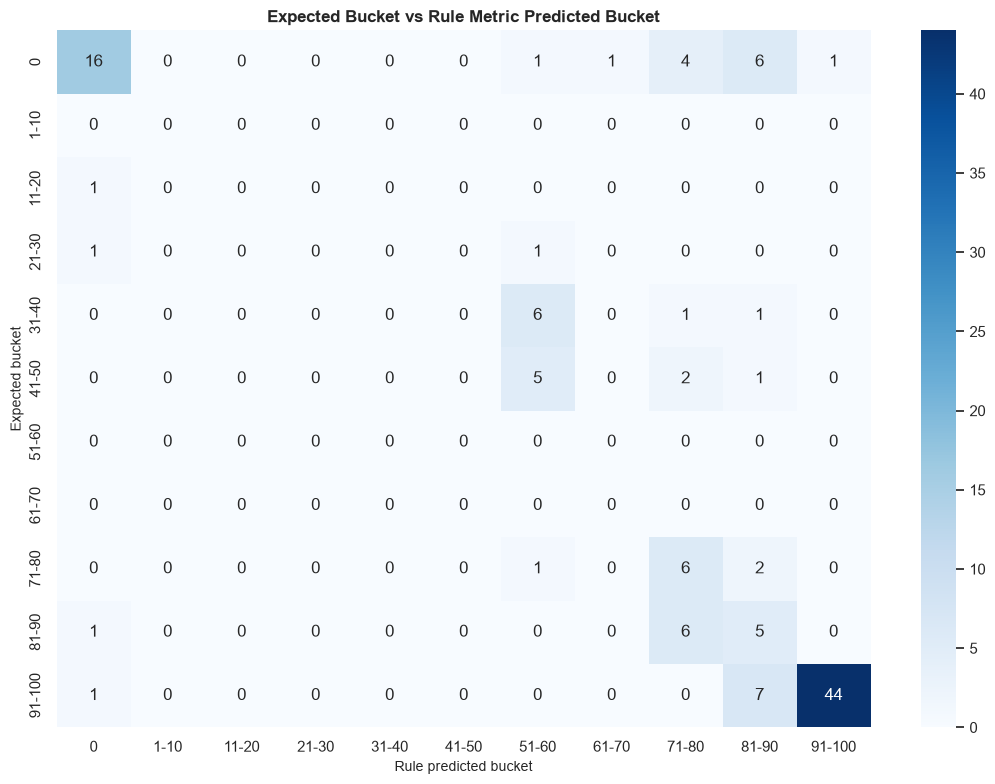

predicted_percentage_bucket,0,1-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100
expected_percentage_bucket,,,,,,,,,,,
0,16,0,0,0,0,0,1,1,4,6,1
1-10,0,0,0,0,0,0,0,0,0,0,0
11-20,1,0,0,0,0,0,0,0,0,0,0
21-30,1,0,0,0,0,0,1,0,0,0,0
31-40,0,0,0,0,0,0,6,0,1,1,0
41-50,0,0,0,0,0,0,5,0,2,1,0
51-60,0,0,0,0,0,0,0,0,0,0,0
61-70,0,0,0,0,0,0,0,0,0,0,0
71-80,0,0,0,0,0,0,1,0,6,2,0


In [41]:
rule_bucket_confusion = pd.crosstab(
    test_rows['expected_percentage_bucket'],
    test_rows['predicted_percentage_bucket'],
).reindex(index=PERCENTAGE_BUCKET_ORDER, columns=PERCENTAGE_BUCKET_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(rule_bucket_confusion, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Expected Bucket vs Rule Metric Predicted Bucket')
ax.set_xlabel('Rule predicted bucket')
ax.set_ylabel('Expected bucket')
plt.tight_layout()
save_figure(fig, 'rule_metric_bucket_confusion')
plt.show()

rule_bucket_confusion

## Model Coarse Bucket Confusion

The trained classifier currently predicts the four coarse labels, so this maps model classes back to `0`, `31-40`, `71-80`, and `91-100`. Use this as a sanity check, not as a true ten-point model.

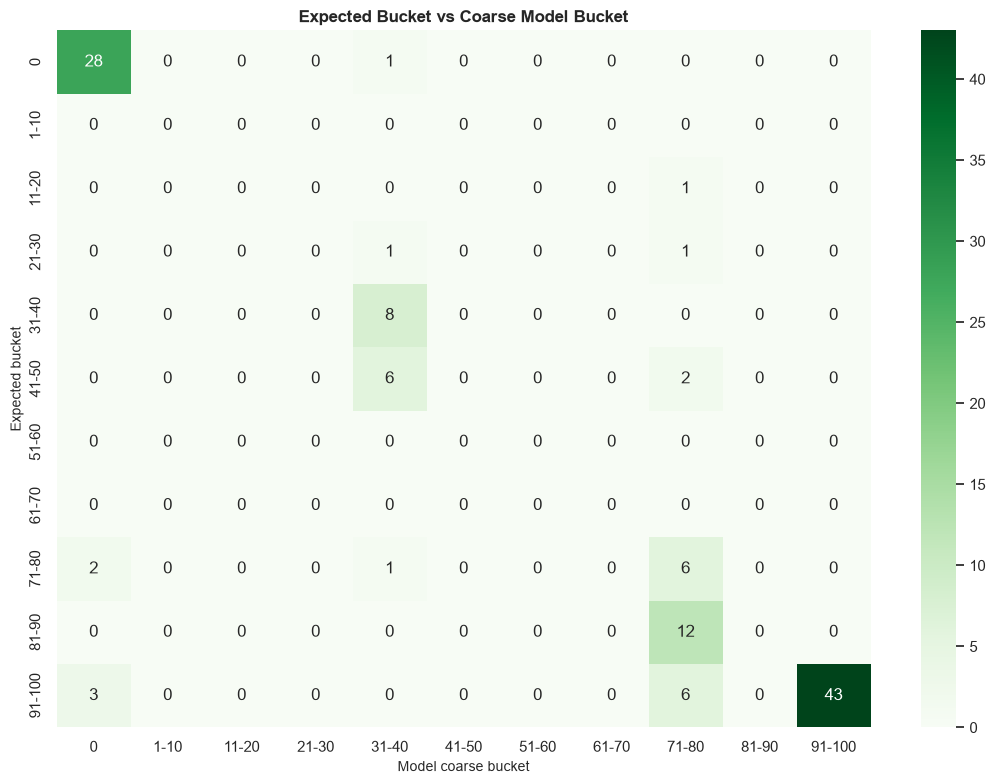

model_percentage_bucket,0,1-10,11-20,21-30,31-40,41-50,51-60,61-70,71-80,81-90,91-100
expected_percentage_bucket,,,,,,,,,,,
0,28,0,0,0,1,0,0,0,0,0,0
1-10,0,0,0,0,0,0,0,0,0,0,0
11-20,0,0,0,0,0,0,0,0,1,0,0
21-30,0,0,0,0,1,0,0,0,1,0,0
31-40,0,0,0,0,8,0,0,0,0,0,0
41-50,0,0,0,0,6,0,0,0,2,0,0
51-60,0,0,0,0,0,0,0,0,0,0,0
61-70,0,0,0,0,0,0,0,0,0,0,0
71-80,2,0,0,0,1,0,0,0,6,0,0


In [42]:
model_bucket_confusion = pd.crosstab(
    test_rows['expected_percentage_bucket'],
    test_rows['model_percentage_bucket'],
).reindex(index=PERCENTAGE_BUCKET_ORDER, columns=PERCENTAGE_BUCKET_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(model_bucket_confusion, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_title('Expected Bucket vs Coarse Model Bucket')
ax.set_xlabel('Model coarse bucket')
ax.set_ylabel('Expected bucket')
plt.tight_layout()
save_figure(fig, 'model_coarse_bucket_confusion')
plt.show()

model_bucket_confusion

## Quick Reading Guide

- If **internal macro F1** is much lower than HF, trust internal more. HF may be easier or cleaner.
- If wrong predictions have high confidence, inspect those rows first. They usually reveal missing features or label noise.
- If feature importance is dominated by one metric, the model may be learning the old rule instead of improving on it.
- If `partial` and `mostly` overlap heavily, that is expected; those labels are the hardest boundary.